In [1]:
import pandas as pd

file = "C:\\SNU EnSite\\2024_JSSP_GA\\result\\250318_initialization_100.csv"
# file = "C:\\SNU EnSite\\2024_JSSP_GA\\result\\250307_BSFS.csv"
result = pd.read_csv(file)
result

,Problem,I_b,I_f,RUBI Ratio,Seed,Best Makespan,Mean Makespan
0,BS_2020_001,0.394737,0.360111,0,2,3126,3705.98
1,BS_2020_001,0.394737,0.360111,100,2,2561,2829.89
2,BS_2020_002,0.415789,0.382271,0,2,3122,3672.44
3,BS_2020_002,0.415789,0.382271,100,2,2507,2751.24
4,BS_2020_003,0.371053,0.365651,0,2,3090,3656.50
...,...,...,...,...,...,...,...
395,FS_2020_098,0.465789,0.764543,100,2,2493,2792.13
396,FS_2020_099,0.423684,0.850416,0,2,3246,3819.17
397,FS_2020_099,0.423684,0.850416,100,2,2378,2766.61
398,FS_2020_100,0.405263,0.819945,0,2,3263,4019.60


In [2]:

# 'Problem' 컬럼에서 unique한 값 추출
unique_problems = result['Problem'].unique()

# 'BS'로 시작하는 값 필터링
bs_problems = [p for p in unique_problems if p.startswith('BS')]
fs_problems = [p for p in unique_problems if p.startswith('FS')]


In [3]:
bs_problems

['BS_2020_001',
 'BS_2020_002',
 'BS_2020_003',
 'BS_2020_004',
 'BS_2020_005',
 'BS_2020_006',
 'BS_2020_007',
 'BS_2020_008',
 'BS_2020_009',
 'BS_2020_010',
 'BS_2020_011',
 'BS_2020_012',
 'BS_2020_013',
 'BS_2020_014',
 'BS_2020_015',
 'BS_2020_016',
 'BS_2020_017',
 'BS_2020_018',
 'BS_2020_019',
 'BS_2020_020',
 'BS_2020_021',
 'BS_2020_022',
 'BS_2020_023',
 'BS_2020_024',
 'BS_2020_025',
 'BS_2020_026',
 'BS_2020_027',
 'BS_2020_028',
 'BS_2020_029',
 'BS_2020_030',
 'BS_2020_031',
 'BS_2020_032',
 'BS_2020_033',
 'BS_2020_034',
 'BS_2020_035',
 'BS_2020_036',
 'BS_2020_037',
 'BS_2020_038',
 'BS_2020_039',
 'BS_2020_040',
 'BS_2020_041',
 'BS_2020_042',
 'BS_2020_043',
 'BS_2020_044',
 'BS_2020_045',
 'BS_2020_046',
 'BS_2020_047',
 'BS_2020_048',
 'BS_2020_049',
 'BS_2020_050',
 'BS_2020_051',
 'BS_2020_052',
 'BS_2020_053',
 'BS_2020_054',
 'BS_2020_055',
 'BS_2020_056',
 'BS_2020_057',
 'BS_2020_058',
 'BS_2020_059',
 'BS_2020_060',
 'BS_2020_061',
 'BS_2020_062',
 'BS_202

In [4]:

def process_problem_group(df, problem_list):
    # 필터링
    filtered_df = df[df['Problem'].isin(problem_list)].copy()
    filtered_df['Problem'] = filtered_df['Problem'].str[-2:]  # 마지막 3자리 유지
    
    # 'Problem' 별로 그룹화
    grouped = filtered_df.groupby('Problem')

    processed_rows = []
    for name, group in grouped:
        
        if len(group) == 4:  # 두 개의 행이 있는 경우에만 처리
            row1, row2 = group.iloc[0], group.iloc[1]
            ratio1 = row2['Best Makespan'] / row1['Best Makespan']
            
            row3, row4 = group.iloc[2], group.iloc[3]
            print(row3['Best Makespan'], row4['Best Makespan'])
            ratio2 = row4['Best Makespan'] / row3['Best Makespan']
            processed_rows.append([name, row1['I_b'], row1['I_f'], (ratio1+ratio2)/2])
        if len(group) == 2:  # 두 개의 행이 있는 경우에만 처리
            row1, row2 = group.iloc[0], group.iloc[1]
            ratio1 = row2['Best Makespan'] / row1['Best Makespan']
            
            # row3, row4 = group.iloc[2], group.iloc[3]
            # ratio2 = row4['Best Makespan'] / row3['Best Makespan']
            processed_rows.append([name, row1['I_b'], row1['I_f'], ratio1])

    return pd.DataFrame(processed_rows, columns=['Problem', 'I_b', 'I_f', 'ratio'])

# BS 및 FS 데이터프레임 생성
bs_data = process_problem_group(result, bs_problems)
fs_data = process_problem_group(result, fs_problems)

# 결과 확인
print(bs_data.head())
print(fs_data.head())

  Problem       I_b       I_f     ratio
0      00  0.981579  0.969529  0.839141
1      01  0.394737  0.360111  0.819258
2      02  0.415789  0.382271  0.803011
3      03  0.371053  0.365651  0.759871
4      04  0.381579  0.401662  0.731436
  Problem       I_b       I_f     ratio
0      00  0.405263  0.819945  0.754827
1      01  0.373684  0.343490  0.758690
2      02  0.363158  0.371191  0.763713
3      03  0.384211  0.415512  0.749022
4      04  0.384211  0.368421  0.733397


In [8]:
fs_data

,Problem,I_b,I_f,ratio
0,00,0.405263,0.819945,0.754827
1,01,0.373684,0.343490,0.758690
2,02,0.363158,0.371191,0.763713
3,03,0.384211,0.415512,0.749022
4,04,0.384211,0.368421,0.733397
...,...,...,...,...
95,95,0.365789,0.775623,0.798740
96,96,0.426316,0.839335,0.782504
97,97,0.392105,0.828255,0.752126
98,98,0.465789,0.764543,0.878126


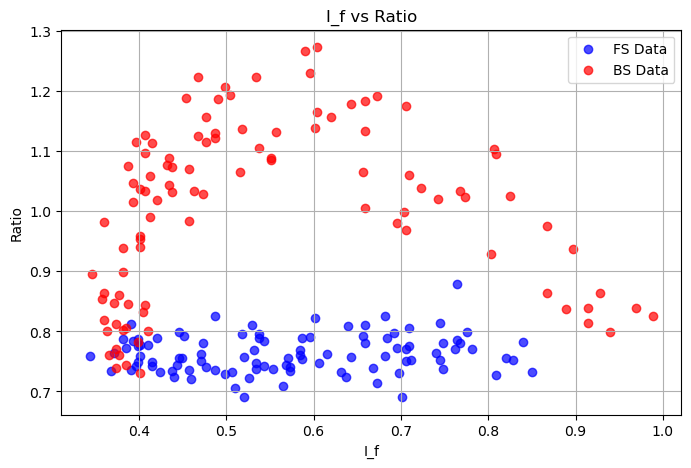

In [6]:
import matplotlib.pyplot as plt

# 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(fs_data['I_f'], fs_data['ratio'], color='b', alpha=0.7, label='FS Data')
plt.scatter(bs_data['I_f'], bs_data['ratio'], color='r', alpha=0.7, label='BS Data')

# 그래프 꾸미기
plt.xlabel('I_f')
plt.ylabel('Ratio')
plt.title('I_f vs Ratio')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()


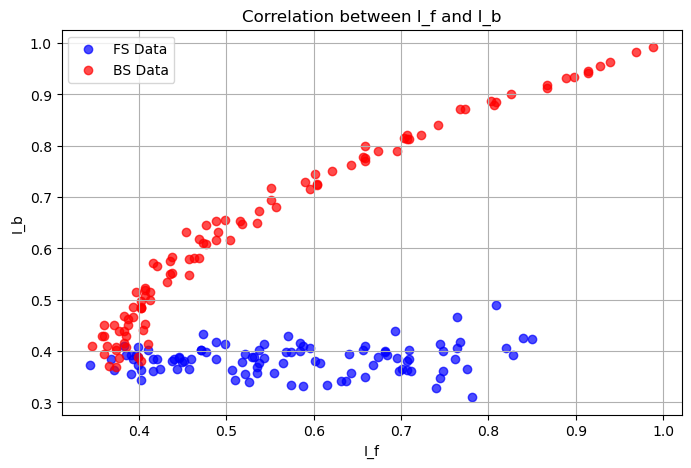

In [9]:
import matplotlib.pyplot as plt

# 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(fs_data['I_f'], fs_data['I_b'], color='b', alpha=0.7, label='FS Data')
plt.scatter(bs_data['I_f'], bs_data['I_b'], color='r', alpha=0.7, label='BS Data')

# 그래프 꾸미기
plt.xlabel('I_f')
plt.ylabel('I_b')
plt.title('Correlation between I_f and I_b')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()


In [61]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update(mpl.rcParamsDefault)

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

# plt.rcParams['font.family'] = 'Times New Roman'

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": 'Times New Roman'
# })
# plt.rcParams.update({'font.size': 14})
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
# 두 값의 correlation 계산
bs_corr = np.corrcoef(bs_data['I_b'], bs_data['I_f'])[0, 1] ** 2
fs_corr = np.corrcoef(fs_data['I_b'], fs_data['I_f'])[0, 1] ** 2

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(11, 6))

# BS Dataset subplot
axes[0].scatter(bs_data['I_b'], bs_data['I_f'], color='r', alpha=0.7, label='BS Data')

# axes[0].set_xlabel(r'\textbf{time (s)}')
axes[0].set_xlabel(r'$I_b$')
axes[0].set_ylabel(r'$I_f$')
axes[0].set_title('BS Dataset', fontsize=BIGGER_SIZE)
axes[0].legend(loc='lower right', bbox_to_anchor=(1, 0))
axes[0].grid(True)
axes[0].set_xlim(-0.03, 1.03)
axes[0].set_ylim(-0.03, 1.03)
axes[0].set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
axes[0].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axes[0].text(0.3 , -0.3, f'$R^2$ = {bs_corr:.4f}', transform=axes[0].transAxes, fontsize=MEDIUM_SIZE)

# FS Dataset subplot
axes[1].scatter(fs_data['I_b'], fs_data['I_f'], color='b', alpha=0.7, label='FS Data')
axes[1].set_xlabel(r'$I_b$')
axes[1].set_ylabel(r'$I_f$')
axes[1].set_title('FS Dataset',fontsize=BIGGER_SIZE)
axes[1].legend(loc='lower right', bbox_to_anchor=(1, 0))
axes[1].grid(True)
axes[1].set_xlim(-0.03, 1.03)
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
axes[1].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axes[1].text(0.3 , -0.3, f'$R^2$ = {fs_corr:.4f}', transform=axes[1].transAxes, fontsize=MEDIUM_SIZE)

# 그래프 표시
plt.tight_layout()
plt.savefig('Dataset.png', bbox_inches='tight', dpi=300)
# plt.savefig('Dataset.eps')
# plt.show()


In [ ]:

axes[1].set_xlim(-0.03, 1.03)
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
axes[1].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])

In [13]:
print('FS data')
print("Min I_f:",min(fs_data['I_f']))
print("Min I_b:",min(fs_data['I_b']))
print("Max I_f:",max(fs_data['I_f']))
print("Max I_b:",max(fs_data['I_b']))
print('BS data')
print("Min I_f:", min(bs_data['I_f']))
print("Min I_b:", min(bs_data['I_b']))
print("Max I_f:",max(bs_data['I_f']))
print("Max I_b:",max(bs_data['I_b']))

FS data
Min I_f: 0.3434903047091412
Min I_b: 0.3105263157894736
Max I_f: 0.8504155124653738
Max I_b: 0.4894736842105263
BS data
Min I_f: 0.3462603878116343
Min I_b: 0.3684210526315789
Max I_f: 0.9889196675900278
Max I_b: 0.9921052631578948


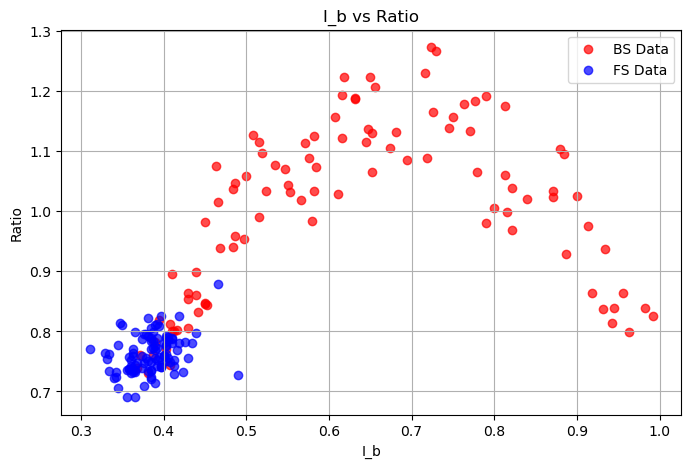

In [7]:

# 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(bs_data['I_b'], bs_data['ratio'], color='r', alpha=0.7, label='BS Data')
plt.scatter(fs_data['I_b'], fs_data['ratio'], color='b', alpha=0.7, label='FS Data')

# 그래프 꾸미기
plt.xlabel('I_b')
plt.ylabel('Ratio')
plt.title('I_b vs Ratio')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()

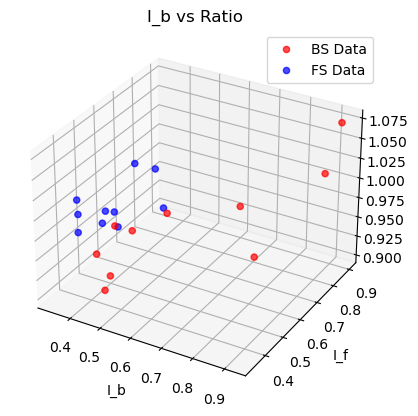

In [66]:
fig = plt.figure()
ax =  fig.add_subplot(111, projection='3d')

ax.scatter(bs_data['I_b'],bs_data['I_f'], bs_data['ratio'], color='r', alpha=0.7, label='BS Data')
ax.scatter(fs_data['I_b'],fs_data['I_f'], fs_data['ratio'], color='b', alpha=0.7, label='FS Data')

# 그래프 꾸미기
plt.xlabel('I_b')
plt.ylabel('I_f')
plt.title('I_b vs Ratio')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()

In [67]:
# import seaborn as sns

# 상관계수 계산
correlation_matrix = fs_data[['I_b', 'I_f', 'ratio']].corr()
print(correlation_matrix)

            I_b       I_f     ratio
I_b    1.000000  0.218313 -0.254503
I_f    0.218313  1.000000 -0.369174
ratio -0.254503 -0.369174  1.000000


In [69]:
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 두 데이터프레임 합치기
combined_data = pd.concat([bs_data, fs_data], ignore_index=True)

# 독립 변수 (X)와 종속 변수 (y) 설정
X = combined_data[['I_b', 'I_f']]
y = combined_data['ratio']

# 상수항 추가 (y 절편 포함)
X = sm.add_constant(X)

# OLS(최소제곱법) 회귀 분석 실행
model = sm.OLS(y, X).fit()

# 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  ratio   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     2.214
Date:                Mon, 17 Mar 2025   Prob (F-statistic):              0.140
Time:                        16:16:41   Log-Likelihood:                 40.352
No. Observations:                  20   AIC:                            -74.70
Df Residuals:                      17   BIC:                            -71.72
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9223      0.029     32.297      0.0